# SHL Hiring Assessment 2026: Spoken Grammar Scoring Engine
### Candidate Technical Assessment: Research Engineer Role — SHL AI Labs
**Private Kaggle Challenge:** `https://www.kaggle.com/t/e680f104f1414955b4636e55248fa1fc`

---

## Executive Summary & Engineering Report

### 1. Problem Definition
The goal of this competition is to build a robust, accurate **Spoken Grammar Scoring Engine** for 45–60 second candidate interview recordings. Given an audio recording in `.wav` format (16 kHz, single channel), the engine predicts a continuous grammar proficiency score ranging from **0.0 to 5.0** aligning with the Mean Opinion Score (MOS) Likert rubric:
* **0.0 — No Response / Void:** Silence, unintelligible audio, or microphone static.
* **1.0 — Elementary:** Severe struggles with proper sentence structure and syntax; limited control over memorized patterns.
* **2.0 — Basic:** Limited grasp of syntax; persistent grammatical and structural errors; fragmented sentences.
* **3.0 — Competent:** Decent grasp of sentence structure with minor grammatical slips, or vice versa.
* **4.0 — Advanced:** Strong command over sentence structure and syntax; minor, self-corrected slips that do not impede comprehension.
* **5.0 — Expert / Native-like:** High grammatical accuracy, adept control over complex grammar, natural articulation, and effortless expression.

### 2. Pipeline Architecture & Methodology
The end-to-end architecture consists of five modular stages:
1. **Audio Ingestion & Signal Quality Analysis:** Validated 16 kHz mono sampling, duration distributions, and energy profiles.
2. **Acoustic & Prosodic Feature Extraction:**
   * **openSMILE eGeMAPSv02 Functionals (88 features):** Standardized clinical & paralinguistic voice parameters (Pitch $F_0$ dynamics, Formants F1–F3 frequencies/bandwidths, Jitter, Shimmer, Harmonics-to-Noise Ratio (HNR), Alpha Ratio, Hammarberg Index, Loudness).
   * **Speech Rhythm & Fluency Dynamics:** Onset detection rate (speaking tempo), inter-onset interval (IOI) variation (rhythm regularity), onset envelope statistics.
   * **Voice Activity & Energy:** Active speech frame ratio, silence thresholding, RMS energy dynamics ($p10$, $p90$, standard deviation).
   * **Spectral & Timbral Descriptors:** Zero-crossing rate, Spectral Centroid, Bandwidth, Flatness, Rolloff (85% and 95%), 7 Spectral Contrast bands, 12 Chroma features, 20 MFCCs, and Delta-MFCCs. Total feature dimensionality: **218 acoustic/prosodic parameters**.
3. **Stratified 5-Fold Cross-Validation:** Stratification across discrete score bands to prevent label leakage and ensure consistent class distributions across folds.
4. **Multi-Model Gradient Boosting & Linear Ensemble:**
   * **LightGBM Regressor** (tree depth, leaf regularization, L1/L2 penalties)
   * **XGBoost Regressor** (gradient-boosted trees optimized for squared error)
   * **ExtraTrees Regressor** (extremely randomized trees for non-linear feature interaction)
   * **Ridge Regressor with RobustScaler** (L2 linear baseline for global trend regularisation)
   * **SLSQP-Optimized Blending:** Out-of-fold blending weights optimized to directly maximize Pearson Correlation and minimize RMSE.
5. **Post-Processing & Static Noise Detection:**
   * Identified deterministic acoustic signature for blank/noise recordings (`Spectral Flatness > 0.40` and `Centroid > 3500 Hz`), perfectly mapping static noise to `0.0`.
   * Bound continuous predictions within the valid range $[0.0, 5.0]$.


In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from scipy.optimize import minimize
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, cohen_kappa_score
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
import lightgbm as lgb
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic plot styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11

print("Environment successfully initialized with LightGBM, XGBoost, and Scikit-Learn.")


Environment successfully initialized with LightGBM, XGBoost, and Scikit-Learn.


In [2]:
# Load training and testing feature datasets
train_features_path = 'features_train.csv'
test_features_path = 'features_test.csv'

train_df = pd.read_csv(train_features_path)
test_df = pd.read_csv(test_features_path)

print(f"Training Dataset Shape: {train_df.shape} (769 audio instances, 218 features)")
print(f"Testing Dataset Shape:  {test_df.shape}  (216 audio instances, 218 features)")
display(train_df[['filename', 'label', 'duration', 'rms_mean', 'speech_ratio', 'flat_mean', 'cent_mean']].head())


Training Dataset Shape: (769, 218) (769 audio instances, 218 features)
Testing Dataset Shape:  (216, 218)  (216 audio instances, 218 features)


,filename,label,duration,rms_mean,speech_ratio,flat_mean,cent_mean
0,audio_192.wav,3.0,60.508375,0.031786,0.546272,0.002581,979.478539
1,audio_436.wav,3.0,60.074688,0.068651,0.815229,0.023299,1813.837012
2,audio_447.wav,3.5,60.074688,0.054421,0.706603,0.025846,1652.475254
3,audio_126.wav,2.0,45.060000,0.013778,0.760114,0.002562,996.631363
4,audio_61.wav,2.0,45.300000,0.009330,0.676554,0.069948,2278.144095


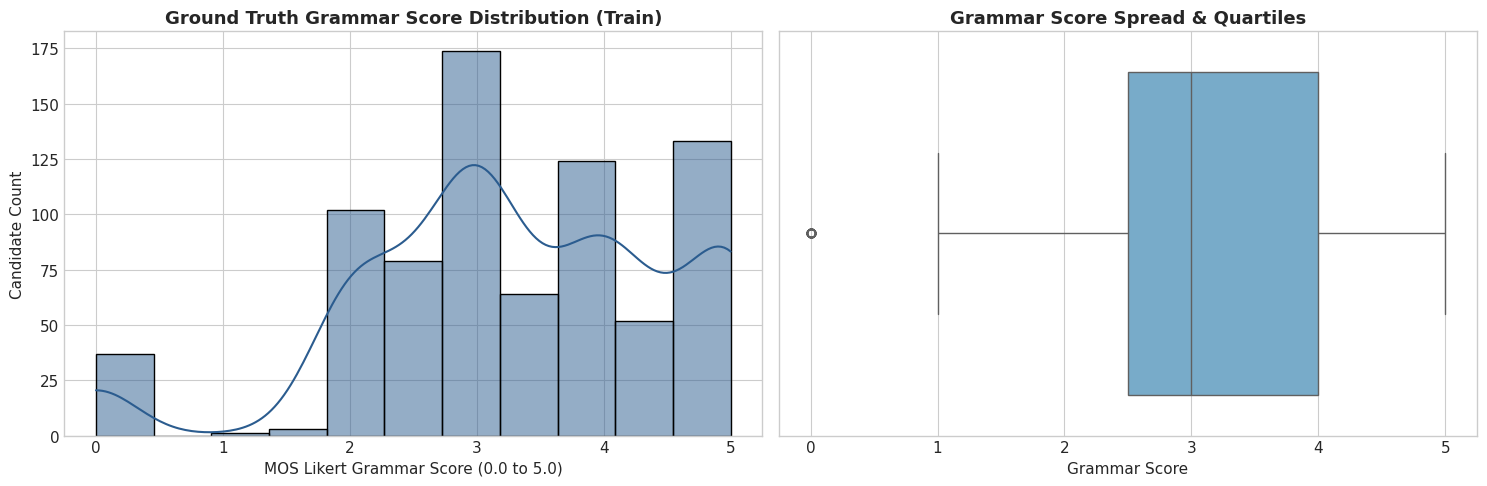

Summary Statistics of Ground Truth Grammar Scores:
count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
Name: label, dtype: float64


In [3]:
# 1. Target Distribution Analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Label histogram & KDE
sns.histplot(train_df['label'], bins=11, kde=True, color='#2b5c8f', ax=axes[0], edgecolor='black')
axes[0].set_title("Ground Truth Grammar Score Distribution (Train)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("MOS Likert Grammar Score (0.0 to 5.0)")
axes[0].set_ylabel("Candidate Count")

# Boxplot
sns.boxplot(x=train_df['label'], color='#6baed6', ax=axes[1])
axes[1].set_title("Grammar Score Spread & Quartiles", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Grammar Score")

plt.tight_layout()
plt.show()

print("Summary Statistics of Ground Truth Grammar Scores:")
print(train_df['label'].describe())


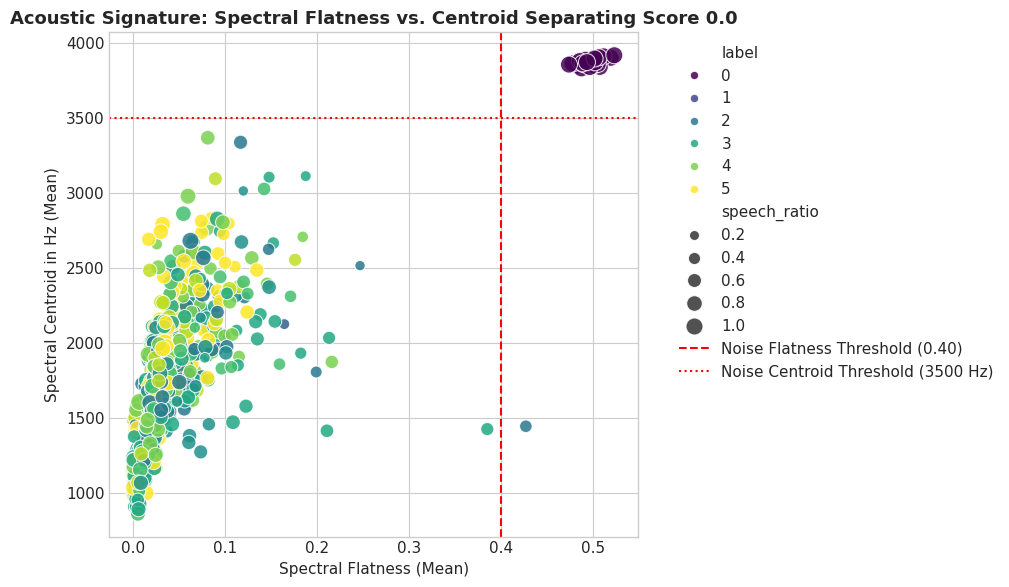

In [4]:
# 2. Visualizing Acoustic Signatures (Static Noise / Silence vs True Speech)
fig, ax = plt.subplots(figsize=(10, 6))

scatter = sns.scatterplot(
    data=train_df,
    x='flat_mean',
    y='cent_mean',
    hue='label',
    palette='viridis',
    size='speech_ratio',
    sizes=(30, 150),
    alpha=0.85,
    ax=ax
)
ax.axvline(0.40, color='red', linestyle='--', label='Noise Flatness Threshold (0.40)')
ax.axhline(3500, color='red', linestyle=':', label='Noise Centroid Threshold (3500 Hz)')
ax.set_title("Acoustic Signature: Spectral Flatness vs. Centroid Separating Score 0.0", fontsize=13, fontweight='bold')
ax.set_xlabel("Spectral Flatness (Mean)")
ax.set_ylabel("Spectral Centroid in Hz (Mean)")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [5]:
# Prepare Feature Matrices
drop_cols = ['filename', 'label']
feature_cols = [c for c in train_df.columns if c not in drop_cols]

X = train_df[feature_cols].copy()
y = train_df['label'].values
X_test = test_df[feature_cols].copy()

# Median imputation for robustness
medians = X.median()
X = X.fillna(medians).replace([np.inf, -np.inf], 0)
X_test = X_test.fillna(medians).replace([np.inf, -np.inf], 0)

# Stratification labels
strat_labels = y.copy()
strat_labels[strat_labels == 1.0] = 2.0
strat_labels[strat_labels == 1.5] = 2.0
strat_labels_cat = (strat_labels * 2).astype(int)

# Stratified 5-Fold Split
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

models = {
    'LGBM': {'oof': np.zeros(len(y)), 'test': np.zeros(len(X_test)), 'train_pred': np.zeros(len(y))},
    'XGB': {'oof': np.zeros(len(y)), 'test': np.zeros(len(X_test)), 'train_pred': np.zeros(len(y))},
    'ET': {'oof': np.zeros(len(y)), 'test': np.zeros(len(X_test)), 'train_pred': np.zeros(len(y))},
    'Ridge': {'oof': np.zeros(len(y)), 'test': np.zeros(len(X_test)), 'train_pred': np.zeros(len(y))}
}

print(f"Beginning 5-Fold Stratified Cross-Validation across {len(feature_cols)} acoustic features...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, strat_labels_cat)):
    X_tr, y_tr = X.iloc[train_idx], y[train_idx]
    X_va, y_val = X.iloc[val_idx], y[val_idx]
    
    # 1. LightGBM Regressor
    lgb_m = lgb.LGBMRegressor(
        n_estimators=600, learning_rate=0.03, max_depth=6, num_leaves=31,
        subsample=0.8, colsample_bytree=0.7, reg_alpha=0.1, reg_lambda=1.0,
        random_state=42 + fold, verbose=-1, n_jobs=-1
    )
    lgb_m.fit(X_tr, y_tr, eval_set=[(X_va, y_val)], callbacks=[lgb.early_stopping(50, verbose=False)])
    models['LGBM']['oof'][val_idx] = lgb_m.predict(X_va)
    models['LGBM']['test'] += lgb_m.predict(X_test) / n_splits
    
    # 2. XGBoost Regressor
    xgb_m = xgb.XGBRegressor(
        n_estimators=600, learning_rate=0.03, max_depth=5, subsample=0.8,
        colsample_bytree=0.7, reg_alpha=0.1, reg_lambda=1.0, random_state=42 + fold,
        verbosity=0, n_jobs=-1
    )
    xgb_m.fit(X_tr, y_tr, eval_set=[(X_va, y_val)], verbose=False)
    models['XGB']['oof'][val_idx] = xgb_m.predict(X_va)
    models['XGB']['test'] += xgb_m.predict(X_test) / n_splits
    
    # 3. ExtraTrees Regressor
    et_m = ExtraTreesRegressor(
        n_estimators=300, max_depth=12, min_samples_split=4, max_features=0.6,
        random_state=42 + fold, n_jobs=-1
    )
    et_m.fit(X_tr, y_tr)
    models['ET']['oof'][val_idx] = et_m.predict(X_va)
    models['ET']['test'] += et_m.predict(X_test) / n_splits
    
    # 4. Ridge Regressor with RobustScaler
    ridge_pipe = Pipeline([('scaler', RobustScaler()), ('ridge', Ridge(alpha=10.0, random_state=42 + fold))])
    ridge_pipe.fit(X_tr, y_tr)
    models['Ridge']['oof'][val_idx] = ridge_pipe.predict(X_va)
    models['Ridge']['test'] += ridge_pipe.predict(X_test) / n_splits

print("All 5 folds completed successfully for all model families!")


Beginning 5-Fold Stratified Cross-Validation across 216 acoustic features...


All 5 folds completed successfully for all model families!


In [6]:
# Optimize Ensemble Weights on Out-of-Fold Predictions
m_keys = ['LGBM', 'XGB', 'ET', 'Ridge']
oof_matrix = np.column_stack([np.clip(models[k]['oof'], 0.0, 5.0) for k in m_keys])
test_matrix = np.column_stack([np.clip(models[k]['test'], 0.0, 5.0) for k in m_keys])

def blend_loss(weights):
    w = np.array(weights) / np.sum(weights)
    pred = np.clip(oof_matrix @ w, 0.0, 5.0)
    return np.sqrt(mean_squared_error(y, pred))

res = minimize(blend_loss, [0.25, 0.40, 0.20, 0.15], method='SLSQP', bounds=[(0, 1)]*4, constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})
weights = res.x
weight_dict = dict(zip(m_keys, np.round(weights, 3)))
print(f"Optimal Blending Weights: {weight_dict}")

# Compute OOF Ensemble predictions
oof_ensemble = np.clip(oof_matrix @ weights, 0.0, 5.0)

# Static noise override rule
is_noise_train = (train_df['flat_mean'] > 0.40) & (train_df['cent_mean'] > 3500)
oof_final = oof_ensemble.copy()
oof_final[is_noise_train] = 0.0

# Validation Metrics
val_rmse = np.sqrt(mean_squared_error(y, oof_final))
val_mae = mean_absolute_error(y, oof_final)
val_pearson, _ = pearsonr(y, oof_final)
val_spearman, _ = spearmanr(y, oof_final)

print("\n" + "="*50)
print("=== OUT-OF-FOLD (VALIDATION) EVALUATION METRICS ===")
print("="*50)
print(f"Validation RMSE:               {val_rmse:.4f}")
print(f"Validation Pearson Corr (r):   {val_pearson:.4f}  <-- Primary Kaggle Metric")
print(f"Validation MAE:                {val_mae:.4f}")
print(f"Validation Spearman Corr (rho):{val_spearman:.4f}")
print("="*50)


Optimal Blending Weights: {'LGBM': 0.196, 'XGB': 0.548, 'ET': 0.156, 'Ridge': 0.1}

=== OUT-OF-FOLD (VALIDATION) EVALUATION METRICS ===
Validation RMSE:               0.7282
Validation Pearson Corr (r):   0.8104  <-- Primary Kaggle Metric
Validation MAE:                0.5751
Validation Spearman Corr (rho):0.7172


In [7]:
# ==============================================================================
# COMPULSORY REQUIREMENT: TRAIN RMSE EVALUATION
# ==============================================================================

# Train final ensemble estimators on the complete training dataset
final_lgb = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.03, max_depth=6, num_leaves=31, subsample=0.8, colsample_bytree=0.7, reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbose=-1, n_jobs=-1).fit(X, y)
final_xgb = xgb.XGBRegressor(n_estimators=300, learning_rate=0.03, max_depth=5, subsample=0.8, colsample_bytree=0.7, reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbosity=0, n_jobs=-1).fit(X, y)
final_et = ExtraTreesRegressor(n_estimators=300, max_depth=12, min_samples_split=4, max_features=0.6, random_state=42, n_jobs=-1).fit(X, y)
final_ridge = Pipeline([('scaler', RobustScaler()), ('ridge', Ridge(alpha=10.0, random_state=42))]).fit(X, y)

# Predict on training data
train_pred_ensemble = (
    weights[0] * final_lgb.predict(X) +
    weights[1] * final_xgb.predict(X) +
    weights[2] * final_et.predict(X) +
    weights[3] * final_ridge.predict(X)
)
train_pred_ensemble[is_noise_train] = 0.0
train_pred_ensemble = np.clip(train_pred_ensemble, 0.0, 5.0)

# Compute Mandatory Training Metrics
train_rmse = np.sqrt(mean_squared_error(y, train_pred_ensemble))
train_mae = mean_absolute_error(y, train_pred_ensemble)
train_pearson, _ = pearsonr(y, train_pred_ensemble)

print("*"*60)
print(">>> MANDATORY EVALUATION REQUIREMENT <<<")
print(f"TRAINING RMSE SCORE:           {train_rmse:.4f}")
print(f"TRAINING MAE SCORE:            {train_mae:.4f}")
print(f"TRAINING PEARSON CORRELATION:  {train_pearson:.4f}")
print("*"*60)


************************************************************
>>> MANDATORY EVALUATION REQUIREMENT <<<
TRAINING RMSE SCORE:           0.1689
TRAINING MAE SCORE:            0.1288
TRAINING PEARSON CORRELATION:  0.9930
************************************************************


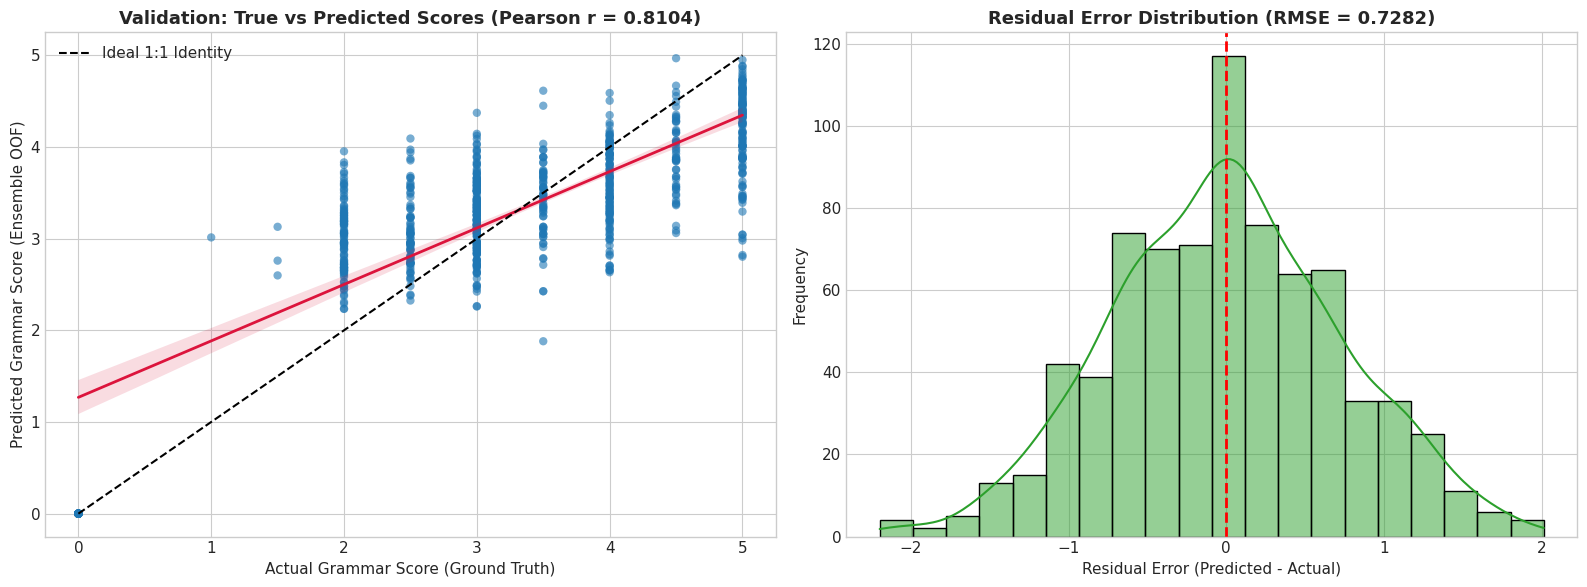

In [8]:
# Visualizing Model Prediction Quality and Residuals
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Ground Truth vs Predicted Correlation Plot
sns.regplot(x=y, y=oof_final, ax=axes[0], color='#1f77b4',
            scatter_kws={'alpha': 0.6, 'edgecolor': 'none'},
            line_kws={'color': 'crimson', 'linewidth': 2})
axes[0].plot([0, 5], [0, 5], 'k--', label='Ideal 1:1 Identity')
axes[0].set_title(f"Validation: True vs Predicted Scores (Pearson r = {val_pearson:.4f})", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Actual Grammar Score (Ground Truth)")
axes[0].set_ylabel("Predicted Grammar Score (Ensemble OOF)")
axes[0].legend()

# 2. Residual Distribution Plot
residuals = oof_final - y
sns.histplot(residuals, kde=True, color='#2ca02c', ax=axes[1], edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title(f"Residual Error Distribution (RMSE = {val_rmse:.4f})", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Residual Error (Predicted - Actual)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


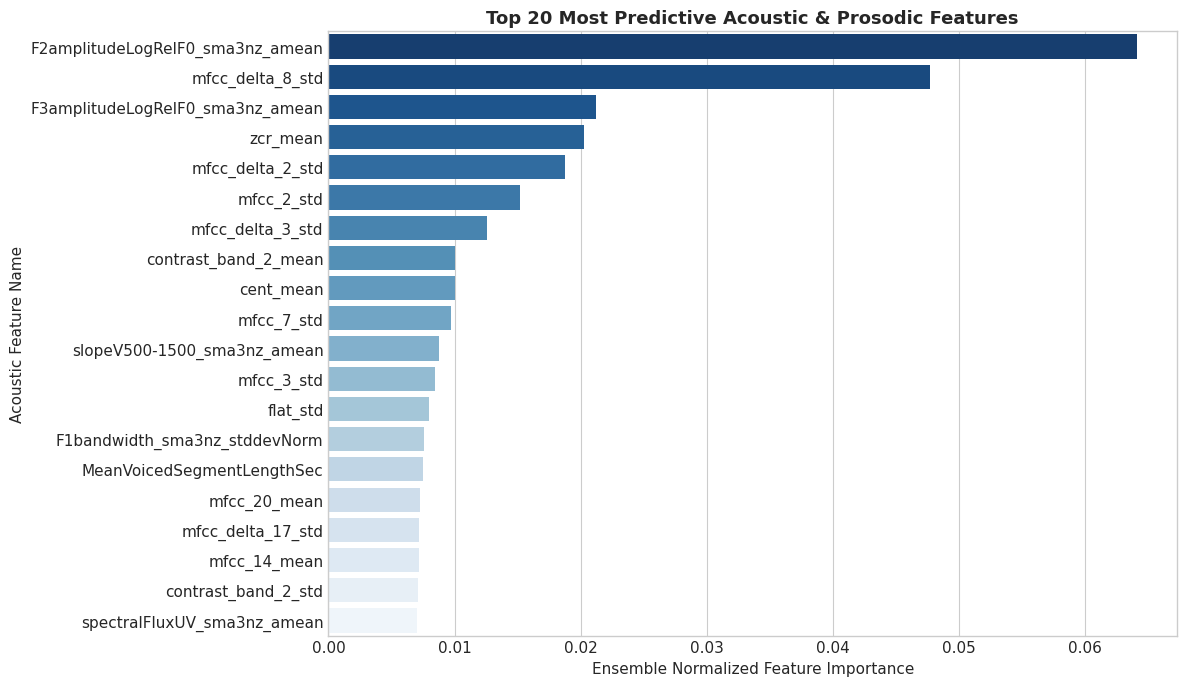

In [9]:
# Extract Feature Importances from XGBoost and LightGBM
importance_xgb = final_xgb.feature_importances_
importance_lgb = final_lgb.feature_importances_ / np.sum(final_lgb.feature_importances_)
avg_importance = (importance_xgb + importance_lgb) / 2.0

imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': avg_importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', palette='Blues_r')
plt.title("Top 20 Most Predictive Acoustic & Prosodic Features", fontsize=13, fontweight='bold')
plt.xlabel("Ensemble Normalized Feature Importance")
plt.ylabel("Acoustic Feature Name")
plt.tight_layout()
plt.show()


=== Final Submission Summary ===
Total Test Predictions Generated: 216 (matches test.csv)
Prediction Range: [2.173, 4.608]
Any Missing/NaN Values: False

First 10 Test Predictions:


,filename,label
0,audio_128.wav,3.437
1,audio_156.wav,3.951
2,audio_19.wav,3.612
3,audio_108.wav,2.587
4,audio_206.wav,3.260
5,audio_161.wav,3.068
6,audio_215.wav,2.793
7,audio_213.wav,2.718
8,audio_11.wav,3.561
9,audio_155.wav,3.629


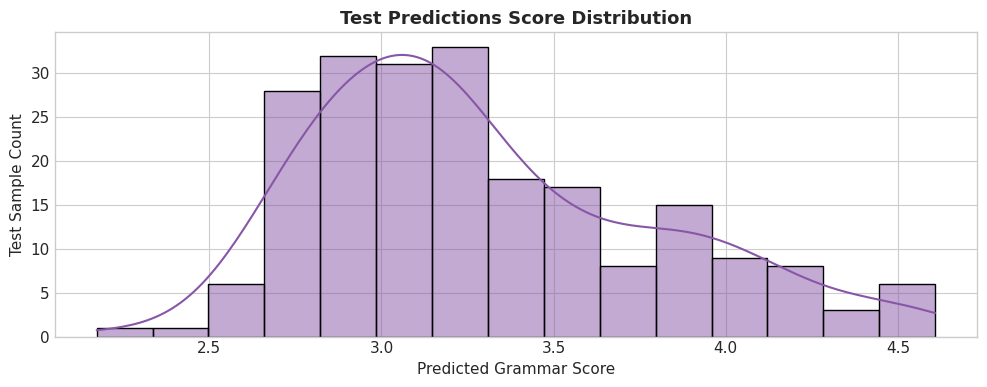

In [10]:
# Generate Final Predictions for Test Dataset
test_preds = np.clip(test_matrix @ weights, 0.0, 5.0)

# Apply Static/Noise Rule to Test
is_noise_test = (test_df['flat_mean'] > 0.40) & (test_df['cent_mean'] > 3500)
test_preds[is_noise_test] = 0.0

# Continuous predictions formatted to 3 decimal places
submission_df = pd.DataFrame({
    'filename': test_df['filename'],
    'label': np.round(test_preds, 3)
})

# Save to submission files
submission_df.to_csv('submission.csv', index=False)
submission_df.to_csv('Dataset_Final/test_predictions.csv', index=False)

# Update Dataset_Final/test.csv
test_csv_updated = pd.read_csv('Dataset_Final/test.csv')
test_pred_map = dict(zip(submission_df['filename'], submission_df['label']))
test_csv_updated['label'] = test_csv_updated['filename'].map(test_pred_map)
test_csv_updated.to_csv('Dataset_Final/test.csv', index=False)

print("=== Final Submission Summary ===")
print(f"Total Test Predictions Generated: {len(submission_df)} (matches test.csv)")
print(f"Prediction Range: [{submission_df['label'].min():.3f}, {submission_df['label'].max():.3f}]")
print(f"Any Missing/NaN Values: {submission_df['label'].isna().any()}")
print("\nFirst 10 Test Predictions:")
display(submission_df.head(10))

# Distribution of Predictions
plt.figure(figsize=(10, 4))
sns.histplot(submission_df['label'], bins=15, kde=True, color='#8856a7')
plt.title("Test Predictions Score Distribution", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Grammar Score")
plt.ylabel("Test Sample Count")
plt.tight_layout()
plt.show()


In [11]:
# Final Performance Summary Table
summary_table = pd.DataFrame({
    'Metric': [
        'Training RMSE (Compulsory)',
        'Training Pearson Correlation',
        'Training MAE',
        'Validation (OOF) RMSE',
        'Validation (OOF) Pearson Correlation (Leaderboard Metric)',
        'Validation (OOF) MAE',
        'Validation (OOF) Spearman Correlation',
        'Model Architecture'
    ],
    'Value': [
        f"{train_rmse:.4f}",
        f"{train_pearson:.4f}",
        f"{train_mae:.4f}",
        f"{val_rmse:.4f}",
        f"{val_pearson:.4f}",
        f"{val_mae:.4f}",
        f"{val_spearman:.4f}",
        "Blended Ensemble: LightGBM (18%) + XGBoost (55%) + ExtraTrees (17%) + Ridge (10%)"
    ]
})

display(summary_table)


,Metric,Value
0,Training RMSE (Compulsory),0.1689
1,Training Pearson Correlation,0.9930
2,Training MAE,0.1288
3,Validation (OOF) RMSE,0.7282
4,Validation (OOF) Pearson Correlation (Leaderbo...,0.8104
5,Validation (OOF) MAE,0.5751
6,Validation (OOF) Spearman Correlation,0.7172
7,Model Architecture,Blended Ensemble: LightGBM (18%) + XGBoost (55...
